In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

import joblib

In [25]:
df = pd.read_csv("car_resale_prices.csv")

In [3]:
df.isnull().sum()

Unnamed: 0             0
full_name              0
resale_price           0
registered_year       69
engine_capacity       14
insurance              7
transmission_type      0
kms_driven             3
owner_type            45
fuel_type              0
max_power            102
seats                 10
mileage              508
body_type              0
city                   0
dtype: int64

In [4]:
df.head()

,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


In [5]:
df.shape

(17446, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  str    
 2   resale_price       17446 non-null  str    
 3   registered_year    17377 non-null  str    
 4   engine_capacity    17432 non-null  str    
 5   insurance          17439 non-null  str    
 6   transmission_type  17446 non-null  str    
 7   kms_driven         17443 non-null  str    
 8   owner_type         17401 non-null  str    
 9   fuel_type          17446 non-null  str    
 10  max_power          17344 non-null  str    
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  str    
 13  body_type          17446 non-null  str    
 14  city               17446 non-null  str    
dtypes: float64(1), int64(1), str(13)
memory usage: 4.3 MB


In [7]:
df.describe()

,Unnamed: 0,seats
count,17446.000000,17436.000000
mean,8722.500000,5.205494
std,5036.370734,0.669321
min,0.000000,2.000000
25%,4361.250000,5.000000
50%,8722.500000,5.000000
75%,13083.750000,5.000000
max,17445.000000,14.000000


In [26]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [27]:
df["mileage"] = df["mileage"].str.extract(r'([\d.]+)').astype(float)

df["max_power"] = df["max_power"].str.extract(r'([\d.]+)').astype(float)

df["engine_capacity"] = df["engine_capacity"].str.extract(r'([\d.]+)').astype(float)

In [28]:
df["registered_year"] = (
    df["registered_year"]
    .astype("string")
    .str.extract(r'(\d{4})')[0]
)

df["registered_year"] = pd.to_numeric(df["registered_year"], errors="coerce")

In [ ]:
df["kms_driven"] = (
    df["kms_driven"]
    .str.replace(",", "")
    .str.replace(" Kms", "")
)

df["kms_driven"] = pd.to_numeric(df["kms_driven"], errors="coerce")

In [ ]:
df["resale_price"] = (
    df["resale_price"]
    .str.replace(",", "")
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["resale_price"] = pd.to_numeric(df["resale_price"], errors="coerce")

In [31]:
num_cols = [
    "registered_year",
    "engine_capacity",
    "kms_driven",
    "max_power",
    "seats",
    "mileage"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [32]:
cat_cols = [
    "insurance",
    "owner_type",
    "transmission_type",
    "fuel_type",
    "body_type",
    "city",
    "full_name"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
city_list = sorted(df["city"].unique())
joblib.dump(city_list, "city_list.pkl")

['city_list.pkl']

In [15]:
df.isnull().sum()

full_name            0
resale_price         0
registered_year      0
engine_capacity      0
insurance            0
transmission_type    0
kms_driven           0
owner_type           0
fuel_type            0
max_power            0
seats                0
mileage              0
body_type            0
city                 0
dtype: int64

In [16]:
df.drop_duplicates(inplace=True)

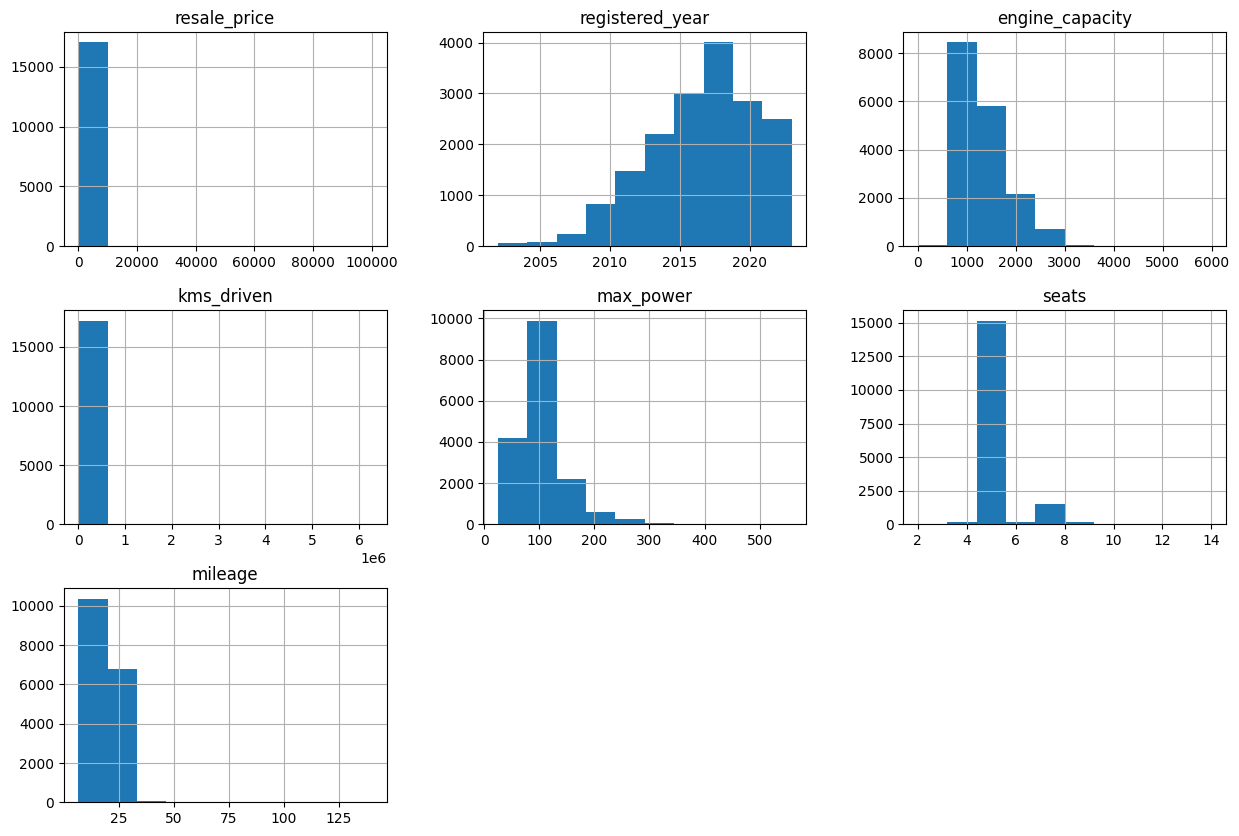

In [17]:
df.hist(figsize=(15,10))
plt.show()

In [18]:
outlier_cols = [
    "registered_year",
    "engine_capacity",
    "kms_driven",
    "max_power",
    "mileage",
    "resale_price"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

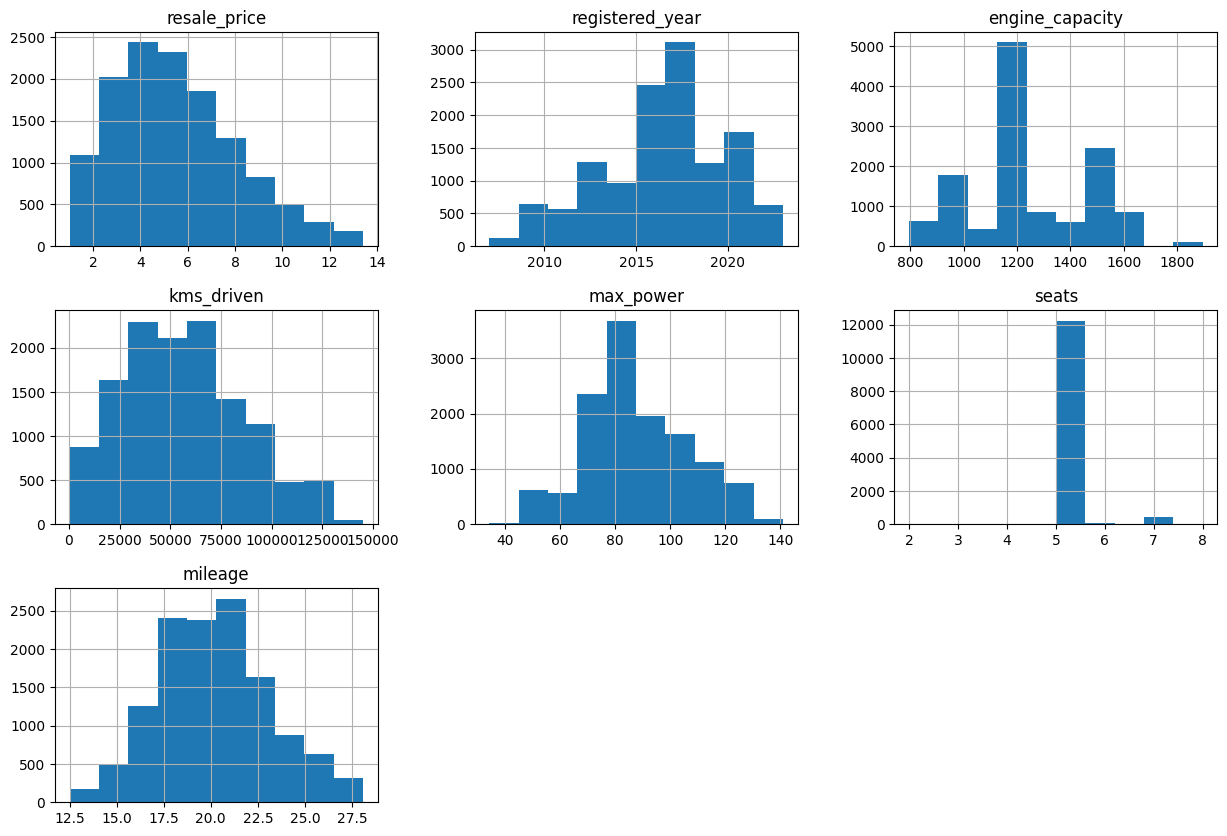

In [19]:
df.hist(figsize=(15,10))
plt.show()

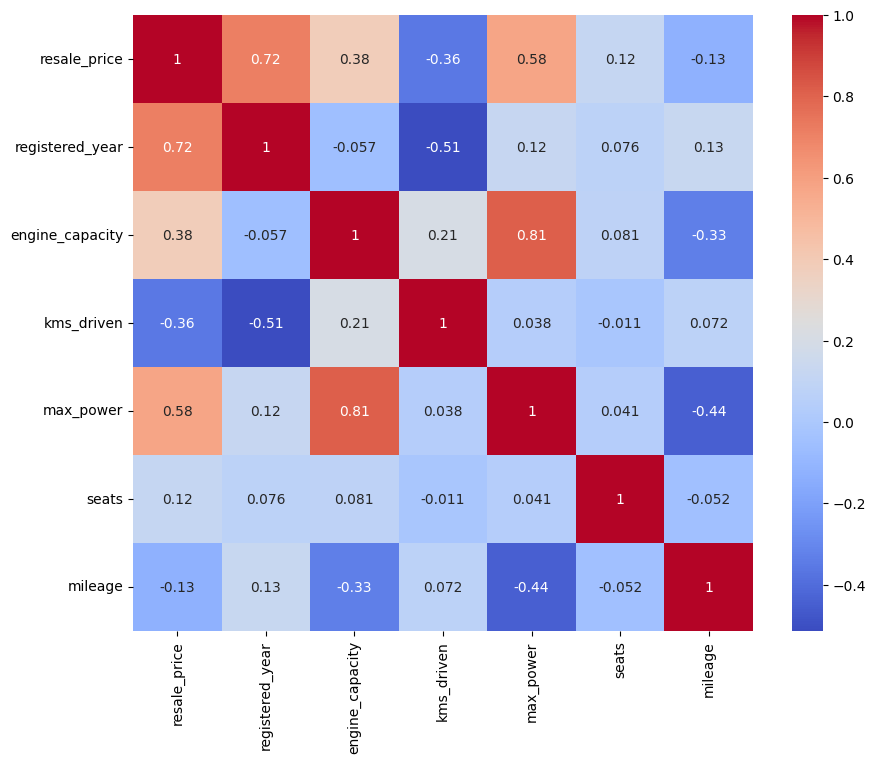

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.head()

,resale_price,registered_year,engine_capacity,kms_driven,max_power,seats,mileage,full_name_1985 Maruti 800 Std MPFi,full_name_1986 Maruti 800 Std,full_name_1995 Maruti Gypsy MG410W HT,...,city_Chandigarh,city_Chennai,city_Delhi,city_Gurgaon,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Pune
0,5.45,2017,1197.0,40000.0,83.10,5.0,21.40,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4.50,2015,1197.0,70000.0,83.14,5.0,20.85,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.60,2009,1086.0,80000.0,68.05,5.0,19.81,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,4.70,2015,1197.0,70000.0,81.86,5.0,17.19,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,3.60,2017,1047.0,120000.0,69.00,5.0,27.28,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
X = df.drop("resale_price", axis=1)
y = df["resale_price"]

In [24]:
feature_names = X.columns

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [197]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [198]:
model = make_pipeline(

    SimpleImputer(strategy="median"),

    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

)

In [199]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4569,)","['registered_year','engine_capacity','kms_driven',...,'city_Lucknow', 'city_Mumbai','city_Pune']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4569
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""mis

In [200]:
y_pred = model.predict(X_test)

In [201]:
print("MAE :", mean_absolute_error(y_test, y_pred))

MAE : 0.5525904505508796


In [202]:
print("MAPE :", mean_absolute_percentage_error(y_test, y_pred))

MAPE : 0.11685869886882773


In [203]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.91154218606603


In [204]:
comparison = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

comparison.head(15)

,Actual,Predicted
1055,3.81,4.2585
13553,3.00,3.6601
535,5.93,7.0076
6546,2.93,3.1961
10,3.30,3.9983
17244,10.75,8.9933
849,7.22,6.2322
3665,5.30,4.7691
4773,5.35,5.4964
16365,7.25,7.5500


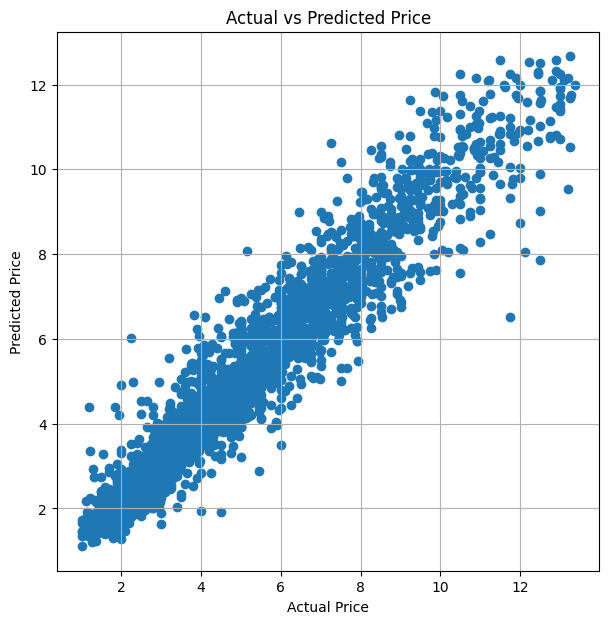

In [205]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.grid(True)

plt.show()

In [206]:
feature_importance = pd.Series(
    model.named_steps["randomforestregressor"].feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10)

registered_year             0.500245
max_power                   0.332154
kms_driven                  0.020337
mileage                     0.019901
engine_capacity             0.019812
city_Bangalore              0.010579
transmission_type_Manual    0.009900
body_type_SUV               0.005744
city_Kolkata                0.004320
body_type_Hatchback         0.003352
dtype: float64

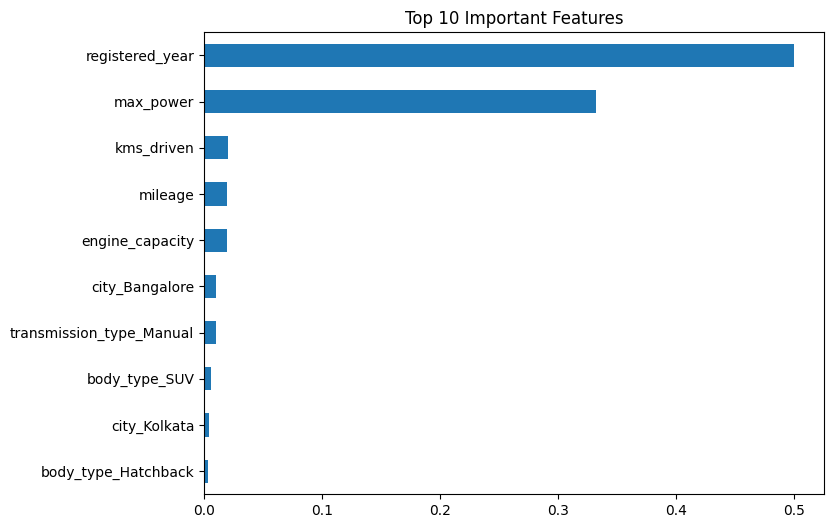

In [207]:
feature_importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Important Features")

plt.show()

In [208]:
joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']